In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
GSE63060_path = "/content/drive/MyDrive/Colab Notebooks/Personal/brain_disease_prediction/GEO/Alzheimer/blood tissue/GSE63060_expression.csv"
GSE63061_path = "/content/drive/MyDrive/Colab Notebooks/Personal/brain_disease_prediction/GEO/Alzheimer/blood tissue/GSE63061_expression.csv"

In [ ]:
GSE63060 = pd.read_csv(GSE63060_path)
GSE63061 = pd.read_csv(GSE63061_path)

In [ ]:
GSE63060.rename(columns={'Unnamed: 0':'patient_id'}, inplace=True)
GSE63061.rename(columns={'Unnamed: 0':'patient_id'}, inplace=True)

In [ ]:
GSE63060.set_index('patient_id', inplace=True)
GSE63061.set_index('patient_id', inplace=True)

In [ ]:
GSE63061

,1-Dec,1-Mar,2-Mar,3-Mar,5-Mar,6-Mar,7-Mar,8-Mar,9-Mar,A1BG,...,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,dJ222E13.2,dJ341D10.1,gm127,psiTPTE22,status
patient_id,,,,,,,,,,,,,,,,,,,,,
GSM1539409,6.046115,6.268807,7.793198,6.247908,6.217792,7.715288,7.880070,6.898175,6.097052,6.363700,...,6.024313,8.223230,9.639303,7.686363,6.312076,6.051220,6.236891,6.114106,6.017242,MCI
GSM1539410,6.068269,6.332623,7.822572,6.253956,6.146553,7.815891,7.950036,6.631771,6.110334,6.038703,...,6.044935,8.423643,10.255327,7.729719,6.234654,6.083923,6.398889,6.144168,6.022783,MCI
GSM1539411,6.049894,6.451657,7.821084,6.299298,6.231308,8.063262,8.578855,7.258313,6.028404,6.149995,...,6.050358,8.126528,9.643614,7.526946,6.441426,6.059549,6.322824,6.043692,6.096135,MCI
GSM1539412,6.022627,6.204796,8.183803,6.242987,6.073113,8.299693,7.528975,7.545952,6.125845,6.364765,...,6.024002,8.443437,9.966027,7.485560,6.167969,6.079597,6.177225,6.192038,6.032421,MCI
GSM1539413,6.024455,6.410122,8.448412,6.185270,6.168115,8.330396,8.040028,7.083462,6.071435,6.154938,...,6.014700,8.657116,9.640727,7.288133,6.422155,6.029469,6.324525,6.072912,6.056553,MCI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM1539792,6.050681,6.393572,7.546375,6.252932,6.226305,8.170299,7.806016,6.963304,6.062263,6.139319,...,6.086113,8.659101,10.350903,7.713113,6.271670,6.104885,6.656707,6.005648,6.031678,MCI
GSM1539793,6.110553,6.376821,8.007593,6.263650,6.138989,8.021647,7.953865,6.968087,5.999827,6.192208,...,6.022127,8.149314,9.762687,7.363716,6.354014,6.010161,6.407741,6.259958,6.103267,MCI
GSM1539794,6.017178,6.375036,7.813062,6.132921,6.176351,8.116965,8.569122,6.976714,6.016029,6.089414,...,6.053900,8.218770,9.624390,7.468304,6.346038,6.088197,6.388553,6.107970,6.044537,AD


In [ ]:
print(len(GSE63060.columns))
print(len(GSE63061.columns))

21697
22337


In [ ]:
common_genes = GSE63060.columns.intersection(GSE63061.columns)

print("Common genes:", len(common_genes))

Common genes: 17154


In [ ]:
GSE63061 = GSE63061[
    GSE63061["status"].isin(["AD", "MCI", "CTL"])
]

# Optional check
print(GSE63061["status"].value_counts())
print(GSE63061.shape)

status
AD     139
CTL    134
MCI    109
Name: count, dtype: int64
(382, 22337)


In [ ]:
GSE63060_common = GSE63060[common_genes]
GSE63061_common = GSE63061[common_genes]

In [ ]:
merged_df = pd.concat(
    [GSE63060_common, GSE63061_common],
    axis=0
)

print(merged_df.shape)

(711, 17154)


In [ ]:
merged_df

,A1BG,A1CF,A26C3,A2BP1,A4GALT,A4GNT,AAA1,AAAS,AACS,AACSL,...,ZYG11A,ZYG11B,ZYX,ZZEF1,ZZZ3,dJ222E13.2,dJ341D10.1,gm127,psiTPTE22,status
patient_id,,,,,,,,,,,,,,,,,,,,,
GSM1539080,7.600951,7.497117,7.476685,7.463816,7.476840,7.499282,7.638083,7.585404,8.148446,7.594694,...,7.462498,10.618034,11.736463,8.561519,7.525411,7.738314,7.786112,7.466882,7.499674,MCI
GSM1539081,7.672496,7.463011,7.651896,7.570863,7.445267,7.656974,7.460855,7.612667,8.315475,7.492516,...,7.472825,11.289126,11.930612,8.697649,7.666053,7.602051,7.707824,7.498424,7.648523,MCI
GSM1539082,7.538046,7.475873,7.461754,7.484247,7.314818,7.530972,7.445645,7.756228,7.912023,7.630822,...,7.435084,11.068854,11.626505,8.889266,7.771253,7.775860,7.764043,7.415565,7.505945,MCI
GSM1539083,7.577860,7.503082,7.488248,7.508958,7.486045,7.542443,7.525906,7.984069,8.064728,7.487097,...,7.377990,10.527572,11.954639,8.665815,7.696854,8.114773,7.459060,7.608580,7.534026,MCI
GSM1539084,7.678150,7.417203,7.481259,7.443698,7.428502,7.436986,7.411262,7.761655,7.977451,7.517720,...,7.453386,10.833655,11.895018,8.785981,7.647086,7.705824,7.563035,7.484933,7.564126,MCI
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GSM1539792,6.139319,6.020684,6.065013,6.040905,6.018924,6.014391,6.112325,6.159050,6.191944,6.325955,...,6.086113,8.659101,10.350903,7.713113,6.271670,6.104885,6.656707,6.005648,6.031678,MCI
GSM1539793,6.192208,6.037401,6.073189,6.018387,6.011448,6.220108,6.050225,6.081145,6.123798,6.240833,...,6.022127,8.149314,9.762687,7.363716,6.354014,6.010161,6.407741,6.259958,6.103267,MCI
GSM1539794,6.089414,6.030420,6.073272,6.032869,6.009287,6.116415,6.056126,6.076175,6.255484,6.174056,...,6.053900,8.218770,9.624390,7.468304,6.346038,6.088197,6.388553,6.107970,6.044537,AD


In [ ]:
merged_df["status"].value_counts()

,count
status,
AD,284
CTL,238
MCI,189


### LOG NORMALIZATION

In [ ]:
X = merged_df.drop(columns=["status"])
y = merged_df["status"]


X_log = np.log2(X + 1)

### VARIANCE FILTERING

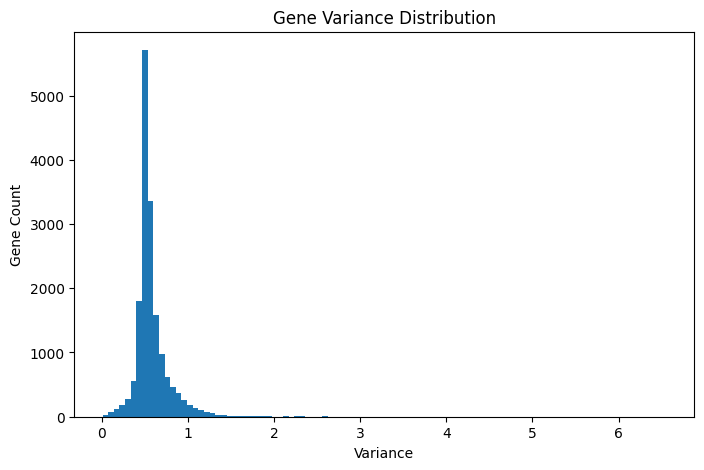

In [ ]:
gene_variance = merged_df.drop(columns=["status"]).var()

plt.figure(figsize=(8,5))
plt.hist(gene_variance, bins=100)
plt.title("Gene Variance Distribution")
plt.xlabel("Variance")
plt.ylabel("Gene Count")
plt.show()

In [ ]:
variance = X_log.var()

threshold = variance.quantile(0.75)

selected_genes = variance[variance > threshold].index

X_filtered = X_log[selected_genes]

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_filtered,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### ANOVA FEATURE SELECTION

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

anova_selector = SelectKBest(score_func=f_classif, k=1000)

X_anova = anova_selector.fit_transform(
    X_train,
    y_train
)

In [ ]:
X_anova.shape

(568, 1000)

### MUTUAL INFORMATION

In [ ]:
from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train,
    y_train
)

mi_df = pd.DataFrame({
    "Gene": X_filtered.columns,
    "MI": mi_scores
}).sort_values("MI", ascending=False)

In [ ]:
top_genes = mi_df["Gene"].head(1000)

X_train_mi = X_train[top_genes]
X_test_mi = X_test[top_genes]

In [ ]:
mi_df

,Gene,MI
4045,UQCRB,0.145165
802,COX17,0.137462
805,COX6C,0.132653
2086,LOC646200,0.128427
385,C16orf7,0.124840
...,...,...
789,COL9A2,0.000000
787,COL23A1,0.000000
786,COL14A1,0.000000
1742,KIAA1600,0.000000


### PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=50)

X_train_pca = pca.fit_transform(X_train)

In [ ]:
X_test_pca = pca.transform(X_test)

### SVD

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=50)

X_train_svd = svd.fit_transform(X_train)

X_test_svd = svd.transform(X_test)

### DEEP AUTOENCODER

In [ ]:
from tensorflow.keras import layers, Model
from tensorflow import keras
import tensorflow as tf

input_dim = X_train.shape[1]

inputs = layers.Input(shape=(input_dim,))

x = layers.Dense(2048, activation='relu')(inputs)
x = layers.Dropout(0.3)(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)

latent = layers.Dense(32, activation='relu', name="latent")(x)

x = layers.Dense(128, activation='relu')(latent)
x = layers.Dense(512, activation='relu')(x)

outputs = layers.Dense(input_dim, activation='linear')(x)

autoencoder = Model(inputs, outputs)
encoder = Model(inputs, latent)

In [ ]:
autoencoder.compile(optimizer='adam', loss='mse')

model = autoencoder.fit(
    X_train,
    X_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 222ms/step - loss: 3.2795 - val_loss: 0.3536
Epoch 2/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 5s 200ms/step - loss: 0.2403 - val_loss: 0.2739
Epoch 3/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 313ms/step - loss: 0.0825 - val_loss: 0.0506
Epoch 4/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - loss: 0.0371 - val_loss: 0.1443
Epoch 5/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 195ms/step - loss: 0.0322 - val_loss: 0.0618
Epoch 6/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 6s 250ms/step - loss: 0.0369 - val_loss: 0.2160
Epoch 7/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 284ms/step - loss: 0.0273 - val_loss: 0.1405
Epoch 8/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 210ms/step - loss: 0.0277 - val_loss: 0.2664
Epoch 9/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step - loss: 0.0254 - val_loss: 0.2073
Epoch 10/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 245ms/step - loss: 0.0256 - val_loss: 0.2686
Epoch 11/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 282ms/step - loss: 0.0311 - val_loss: 0.2024
Epoch 12/50
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 200ms/step

In [ ]:
X_train_ae = encoder.predict(X_train)
X_test_ae = encoder.predict(X_test)

18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


In [ ]:
len(X_test_ae)

143

# 1. RF Model


In [ ]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

model_rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import numpy as np

def model_report(name, y_test, y_pred):
    print("\n" + "="*60)
    print(f"📊 MODEL REPORT: {name}")
    print("="*60)

    print("\n🔹 Accuracy:")
    print(accuracy_score(y_test, y_pred))

    print("\n🔹 Classification Report:")
    print(classification_report(y_test, y_pred))

    print("\n🔹 Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

In [ ]:
model_rf.fit(X_train_pca, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [ ]:
y_val_pred = model_rf.predict(X_test_pca)

model_report("PCA + MLP", y_test, y_val_pred)


📊 MODEL REPORT: PCA + MLP

🔹 Accuracy:
0.5524475524475524

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.84      0.65        57
           1       0.65      0.54      0.59        48
           2       0.38      0.13      0.20        38

    accuracy                           0.55       143
   macro avg       0.52      0.51      0.48       143
weighted avg       0.53      0.55      0.51       143


🔹 Confusion Matrix:
[[48  4  5]
 [19 26  3]
 [23 10  5]]


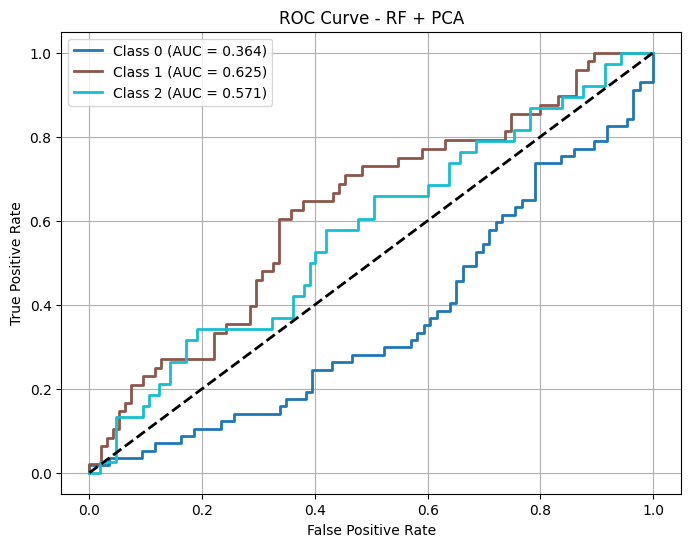

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import numpy as np
import matplotlib.pyplot as plt

# probabilities
y_proba = model_svm.predict_proba(X_test_pca)

# classes
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(classes)):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# plot
plt.figure(figsize=(8,6))

colors = plt.cm.tab10(np.linspace(0, 1, len(classes)))

for i in range(len(classes)):
    plt.plot(
        fpr[i],
        tpr[i],
        color=colors[i],
        lw=2,
        label=f"Class {classes[i]} (AUC = {roc_auc[i]:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--", lw=2)

plt.title("ROC Curve - RF + PCA")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid()

plt.show()

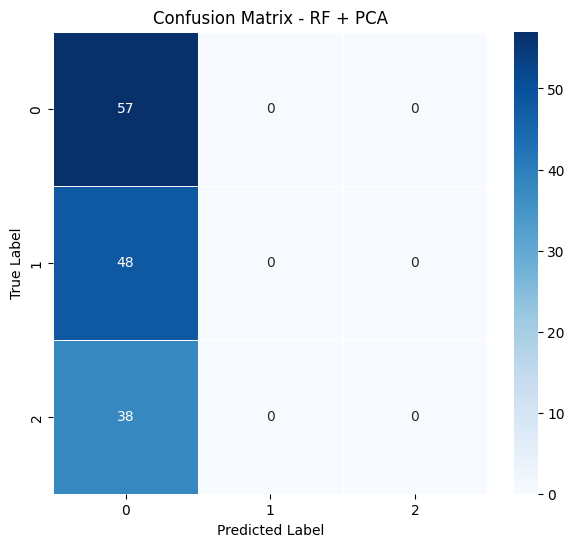

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# predictions
y_pred = model_svm.predict(X_test_pca)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5
)

plt.title("Confusion Matrix - RF + PCA")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
model_svm.fit(X_train_ae, y_train)

SVC(probability=True)

In [ ]:
y_pred_ae = model_svm.predict(X_test_ae)
y_proba_ae = model_svm.predict_proba(X_test_ae)

model_report("AE + MLP", y_test, y_pred_ae)


📊 MODEL REPORT: AE + MLP

🔹 Accuracy:
0.3986013986013986

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.40      1.00      0.57        57
           1       0.00      0.00      0.00        48
           2       0.00      0.00      0.00        38

    accuracy                           0.40       143
   macro avg       0.13      0.33      0.19       143
weighted avg       0.16      0.40      0.23       143


🔹 Confusion Matrix:
[[57  0  0]
 [48  0  0]
 [38  0  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
model_svm.fit(X_train_svd, y_train)

SVC(probability=True)

In [ ]:
y_pred_svd = model_svm.predict(X_test_svd)
y_proba_svd = model_svm.predict_proba(X_test_svd)

model_report("AE + MLP", y_test, y_pred_ae)


📊 MODEL REPORT: AE + MLP

🔹 Accuracy:
0.3986013986013986

🔹 Classification Report:
              precision    recall  f1-score   support

           0       0.40      1.00      0.57        57
           1       0.00      0.00      0.00        48
           2       0.00      0.00      0.00        38

    accuracy                           0.40       143
   macro avg       0.13      0.33      0.19       143
weighted avg       0.16      0.40      0.23       143


🔹 Confusion Matrix:
[[57  0  0]
 [48  0  0]
 [38  0  0]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
history_mi = model_xgb.fit(
    X_train_mi,
    y_train,
    eval_set=[(X_test_mi, y_test)],
    verbose=True
)

NameError: name 'model_xgb' is not defined

In [ ]:
y_pred_mi = model_xgb.predict(X_test_mi)

model_report("PCA + MLP", y_test, y_pred_mi)

# XAI

In [ ]:
X_latent = encoder.predict(X_filtered)

In [ ]:
import shap

explainer = shap.Explainer(model.predict, X_train)

shap_values = explainer(X_test)

In [ ]:
import umap.umap_ as umap

reducer = umap.UMAP()

embedding = reducer.fit_transform(X_latent)